# Melodic Responsion

In [1]:
from pathlib import Path

def find_project_root(start: Path, markers=("pyproject.toml", ".git")):
    for p in [start] + list(start.parents):
        if any((p / m).exists() for m in markers):
            return p
    raise RuntimeError("Project root not found")

ROOT = find_project_root(Path.cwd())

print(ROOT)

/home/urdatorn/git/gh/aristophanis-cantica


## Corpus

Conser's Aeschylus: **80.2%** compatibility.

In [2]:
from collections import Counter

from responsio_accentuum import compatibility_corpus, compatibility_ratios_to_stats

all_sets = compatibility_corpus(ROOT / 'data/compiled/')
total_comp = compatibility_ratios_to_stats(all_sets)

print(f'\nTotal compatibility: {total_comp} = \033[92m{float(total_comp)}\033[0m\n')

found_zero = False
number_of_variables = 0
value_distribution = {
    '0': 0,
    '1/4': 0,
    '1/3:': 0,
    '1/2': 0,
    '2/3': 0,
    '3/4': 0,
    '1': 0,
}

values = []
for element in all_sets:
    for subelement in element:
        for subsubelement in subelement:
            for value in subsubelement:
                number_of_variables += 1
                values.append(value)
                if value == 0.0:
                    found_zero = True
                

print(f'Number of variables: {number_of_variables}\n')

count_dict = Counter(values)

for count in count_dict:
    print(f'{count}: {count_dict[count]}')


12it [00:00, 68.39it/s]                       


Total compatibility: 5125/6604 = 0.7760448213204119

Number of variables: 6604

1: 5062
0: 1416
1/2: 126


To test Wahlström's specific conjecture that responsion is tighter towards the ends of lines, we reverse all the inner lists before averaging.

## Play

In [3]:
from responsio_accentuum import compatibility_play, compatibility_ratios_to_stats
from aristophanis_cantica.utils.utils import abbreviations

def prepare_compatibility_stat(abbreviation):
    ratios = compatibility_play(ROOT / f"data/compiled/responsion_{abbreviation}_compiled.xml")
    return compatibility_ratios_to_stats(ratios)  # stays Fraction

# Keep exact values for downstream logic
play_dict_fraction = {}
for play in abbreviations:
    stat = prepare_compatibility_stat(play)
    play_dict_fraction[play] = stat
    print(f"\t{play}:\t{stat} ({float(stat):.6f})")

# Convert only at visualization boundary
play_dict = {k: float(v) for k, v in play_dict_fraction.items()}

	ach:	1485/1912 (0.776674)
	eq:	269/348 (0.772989)
	nu:	4/5 (0.800000)
	v:	641/808 (0.793317)
	pax:	501/665 (0.753383)
	av:	598/769 (0.777633)
	lys:	571/728 (0.784341)
	th:	155/203 (0.763547)
	ra:	1249/1676 (0.745227)
	ec:	134/175 (0.765714)
	pl:	42/47 (0.893617)


There is a weak linear correlation, but if we exclude Plutus the slope decreases by a full order of magnitude.

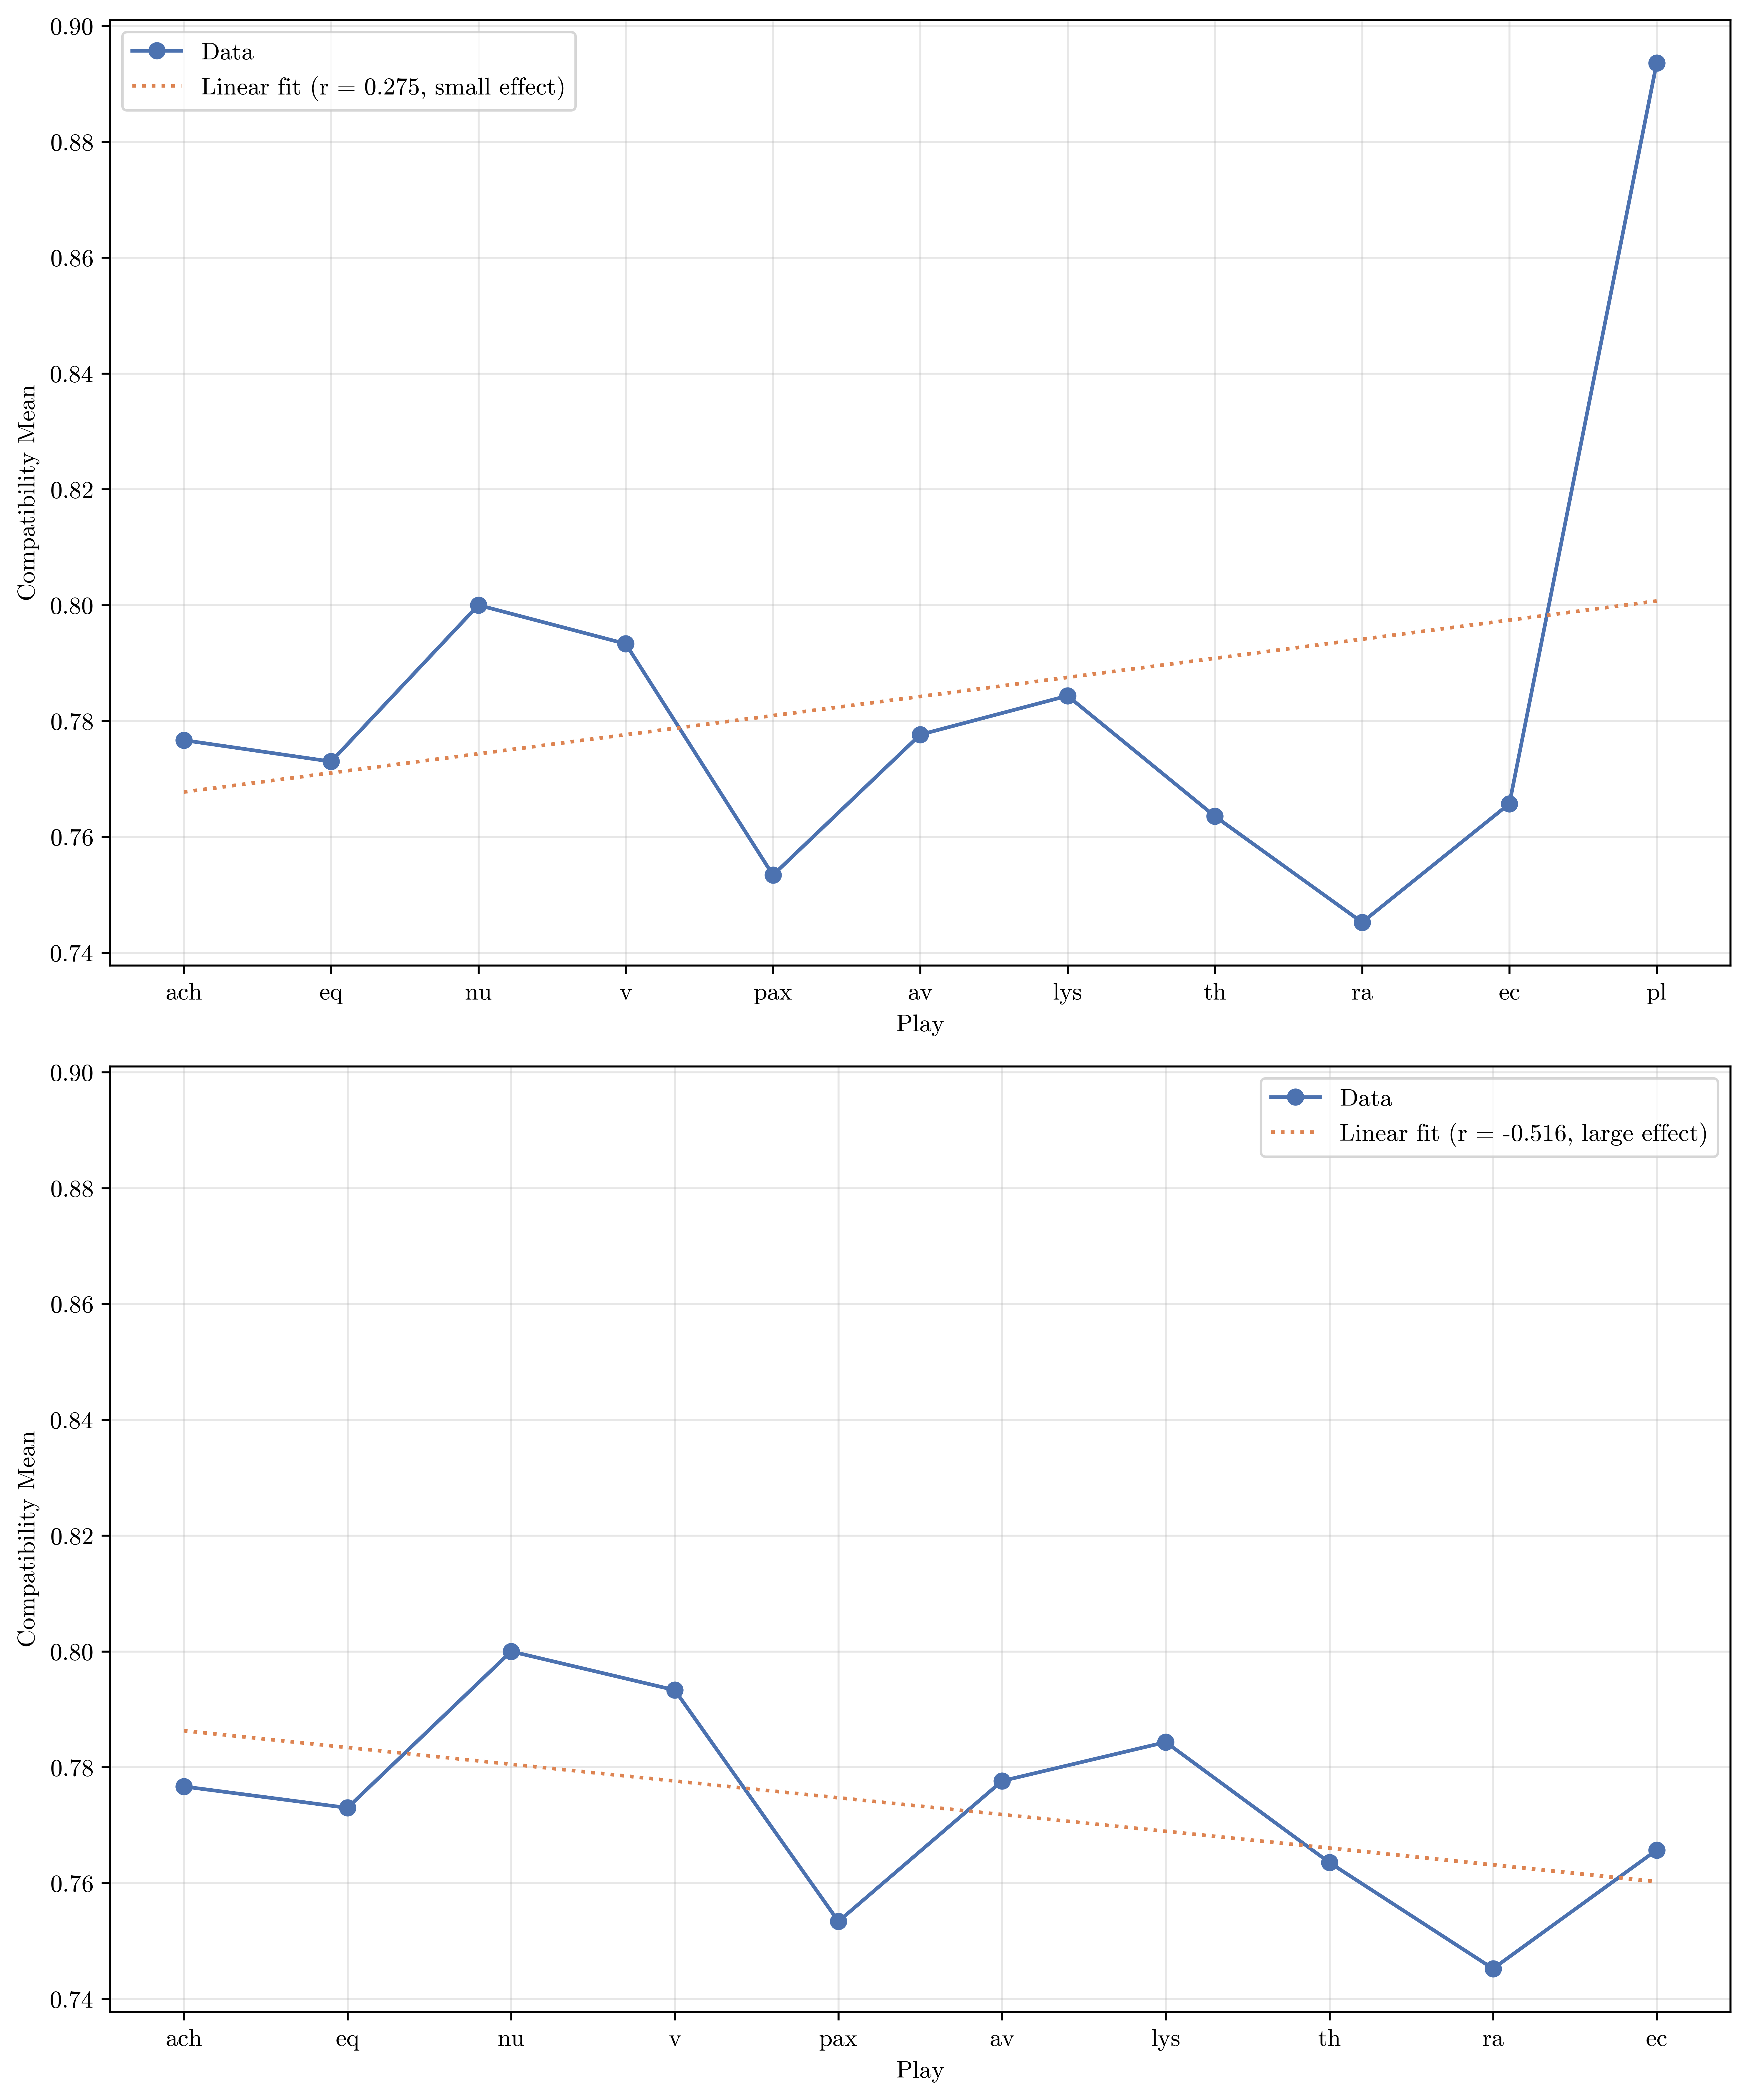

In [6]:
import matplotlib.pyplot as plt
from scipy.stats import linregress
from aristophanis_cantica.plot import apply_plotting_poetry_palette
from aristophanis_cantica.utils.utils import get_cohen_category

apply_plotting_poetry_palette()
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

def plot_regression_on_ax(ax, data, title):
    # Convert keys to numeric x positions
    x = list(range(len(data)))
    labels = list(data.keys())

    # Keep exact values in `data`; convert to float only at regression/plot boundary
    y = [float(v) for v in data.values()]

    # Linear regression
    slope, intercept, r_value, *_ = linregress(x, y)
    regression_line = [slope * xi + intercept for xi in x]

    # Plot
    ax.plot(x, y, marker="o", color=default_colors[0], label="Data")
    ax.plot(
        x,
        regression_line,
        color=default_colors[1],
        linestyle=":",
        label=f"Linear fit (r = {r_value:.3f}, {get_cohen_category(r_value)} effect)",
    )

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_xlabel("Play")
    ax.set_ylabel("Compatibility Mean")
    #ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()


# Build datasets
data_with_pl = play_dict
data_without_pl = {k: v for k, v in play_dict.items() if k != "pl"}

# Single figure with two subplots
fig, axes = plt.subplots(2, 1, figsize=(10, 12), sharey=True)

plot_regression_on_ax(
    axes[0],
    data_with_pl,
    "Linear Regression of Play Compatibility",
)
plot_regression_on_ax(
    axes[1],
    data_without_pl,
    "Linear Regression of Play Compatibility (Excl. Plutus)",
)

plt.tight_layout()
plt.savefig(ROOT / "media/play_regression/linreg_comp.png", dpi=600)
plt.show()

Let's do it for Conser's Aeschylus:

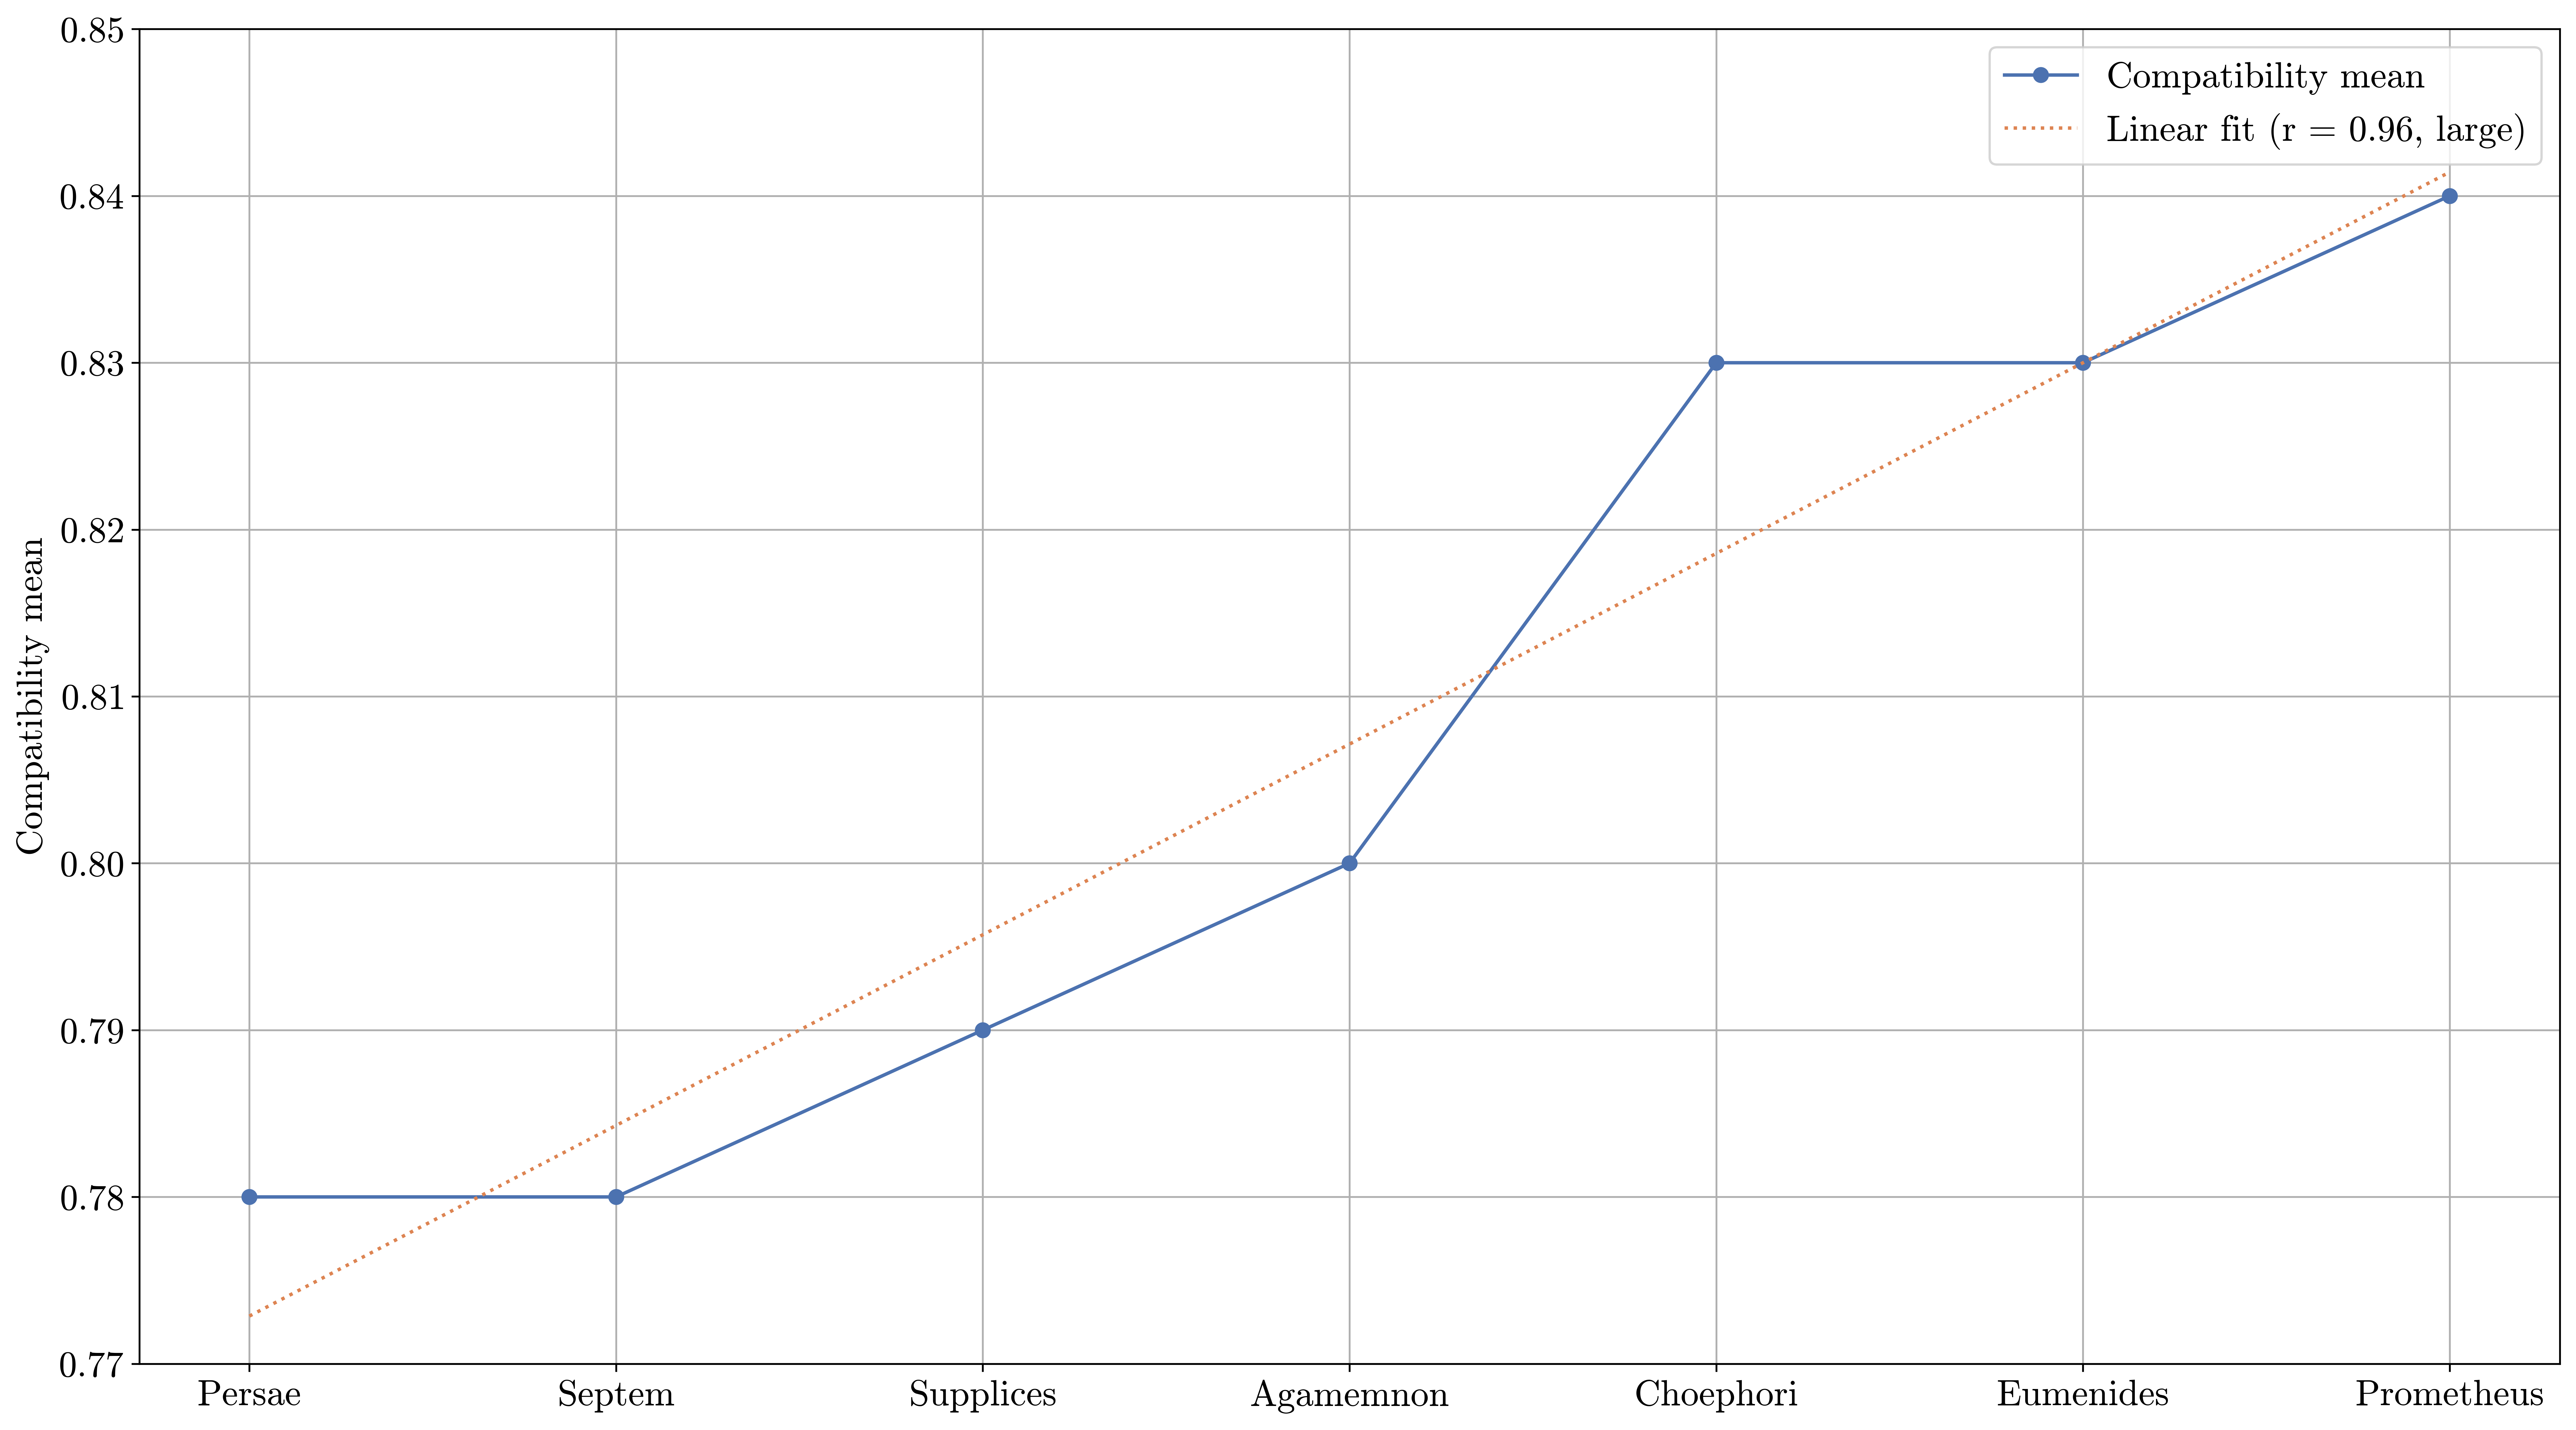

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress, pearsonr
from aristophanis_cantica.plot import apply_plotting_poetry_palette

apply_plotting_poetry_palette()
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

#increase font size
plt.rcParams.update({'font.size': 16})

# Data
plays = [
    "Persae", "Septem", "Supplices", 
    "Agamemnon", "Choephori", "Eumenides", "Prometheus"
]
compatibility_means = [0.78, 0.78, 0.79, 0.80, 0.83, 0.83, 0.84]

# Numeric x-values for regression
x_numeric = np.arange(len(plays))
y = np.array(compatibility_means)

# Linear regression
slope, intercept, r_value, p_value, std_err = linregress(x_numeric, y)
regression_line = slope * x_numeric + intercept

# Cohen's interpretation
def interpret_r(r):
    abs_r = abs(r)
    if abs_r < 0.10:
        return "negligible"
    elif abs_r < 0.30:
        return "small"
    elif abs_r < 0.50:
        return "medium"
    else:
        return "large"


r_interpretation = interpret_r(r_value)

# Plotting
plt.figure(figsize=(16, 9))
plt.plot(plays, compatibility_means, marker='o', color=default_colors[0], label="Compatibility mean")
plt.plot(plays, regression_line, color=default_colors[1], linestyle=':', label=f"Linear fit (r = {r_value:.2f}, {r_interpretation})")
plt.ylabel("Compatibility mean")
#plt.title("Comparison: Significant Linear Regression of Play Compatibility for Conser's Aeschylus")
plt.ylim(0.77, 0.85)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(ROOT / 'media/play_regression/linreg_aeschylus.png', dpi=600)
plt.show()


## Canticum

['ach01', 'ach02', 'ach03', 'ach04', 'ach05', 'ach06', 'ach07', 'ach08', 'ach09', 'eq01', 'eq02', 'eq03', 'eq04', 'eq05', 'eq06', 'eq07', 'eq08', 'nu01', 'nu02', 'nu03', 'nu04', 'nu05', 'nu06', 'v01', 'v02', 'v03', 'v04', 'v05', 'v06', 'v07', 'v08', 'pax01', 'pax02', 'pax03', 'pax04', 'pax05', 'pax06', 'av01', 'av02', 'av03', 'av04', 'av05', 'av06', 'av07', 'av08', 'av09', 'av10', 'lys01', 'lys02', 'lys03', 'lys04', 'lys05', 'lys06', 'lys07', 'lys08', 'th01', 'th02', 'th03', 'th04', 'ra01', 'ra02', 'ra03', 'ra04', 'ra05', 'ra06', 'ra07', 'ra08', 'ra09', 'ra10', 'ra11', 'ec01', 'ec02', 'ec03', 'ec04', 'ec05', 'ec06', 'pl01', 'pl02']
Number of cantica: 78


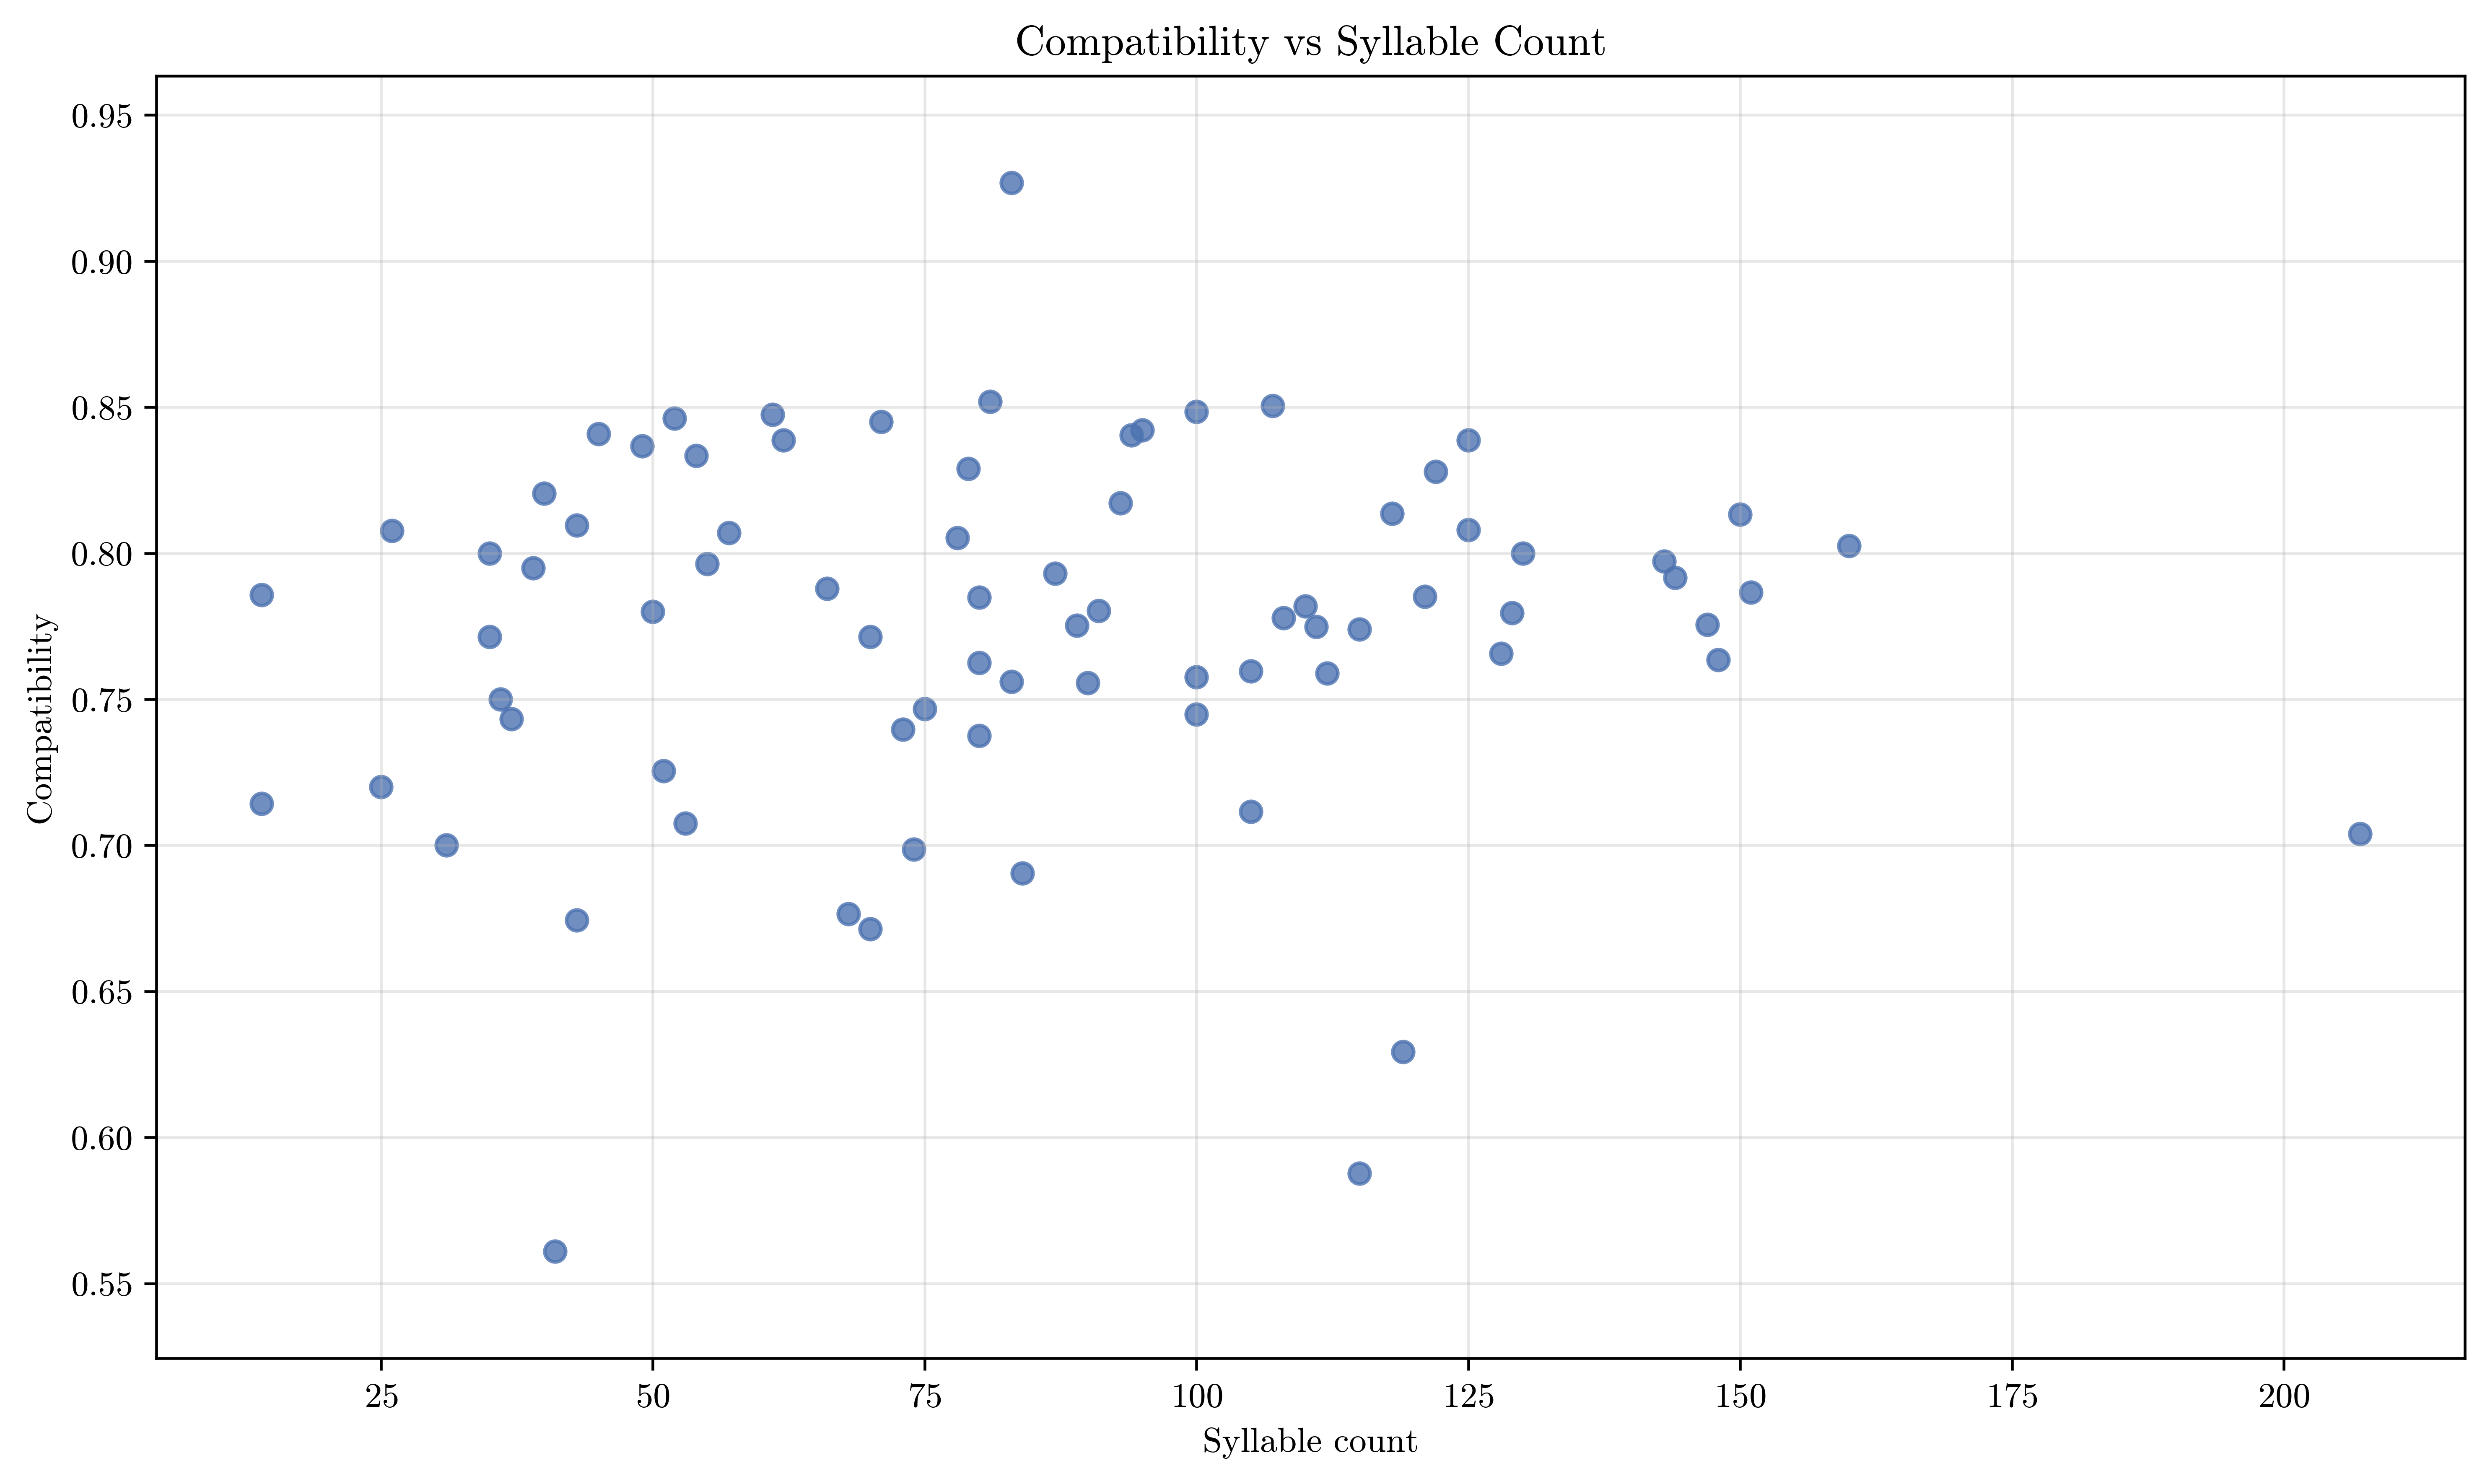

In [ ]:
# Replace the Canticum cell with this

import matplotlib.pyplot as plt
import numpy as np
from aristophanis_cantica.plot import apply_plotting_poetry_palette
from responsio_accentuum import compatibility_canticum, compatibility_ratios_to_stats
from aristophanis_cantica.utils.utils import abbreviations, get_canticum_ids, get_syll_count

apply_plotting_poetry_palette()

def prepare_compatibility_stat_canticum(canticum_id):
    ratios = compatibility_canticum(
        ROOT / f"data/compiled/responsion_{canticum_id[:-2]}_compiled.xml",
        canticum_id,
    )
    return compatibility_ratios_to_stats(ratios)  # keep Fraction upstream

canticum_ids = get_canticum_ids(abbreviations)
print(canticum_ids)
syll_counts = get_syll_count(canticum_ids)

# Keep exact values first
canticum_dict_fraction = {}
for canticum_id in canticum_ids:
    canticum_dict_fraction[canticum_id] = prepare_compatibility_stat_canticum(canticum_id)

print("Number of cantica:", len(canticum_ids))

# Convert only at plotting/regression boundary
canticum_dict = {k: float(v) for k, v in canticum_dict_fraction.items()}

plays = list(canticum_dict.keys())
stats = [canticum_dict[k] for k in plays]

prefixes = [key[:-2] for key in plays]
unique_prefixes = sorted(set(prefixes))
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

prefix_to_color = {
    prefix: default_colors[i % len(default_colors)]
    for i, prefix in enumerate(unique_prefixes)
}
colors = [prefix_to_color[key[:-2]] for key in plays]

x = np.arange(len(stats), dtype=float)
y = np.array(stats, dtype=float)

slope, intercept = np.polyfit(x, y, 1)
regression_line = slope * x + intercept
r_value = np.corrcoef(x, y)[0, 1]

def get_cohen_category(r):
    abs_r = abs(r)
    if abs_r >= 0.5:
        return "Large"
    if abs_r >= 0.3:
        return "Medium"
    if abs_r >= 0.1:
        return "Small"
    return "Negligible"

cohen_category = get_cohen_category(r_value)

vmin, vmax = min(stats), max(stats)
pad = max((vmax - vmin) * 0.10, 0.01)
y_start = max(0.0, vmin - pad)
y_end = min(1.0, vmax + pad)

# Explicit bar + regression plot
plt.figure(figsize=(16, 9))
plt.bar(plays, stats, color=colors)
plt.plot(
    plays,
    regression_line,
    color=default_colors[1],
    linewidth=4,
    linestyle=":",
    label=f"Linear fit (r = {r_value:.2f}, {cohen_category} effect by Cohen convention)",
)
plt.xlabel("Songs, colour-coded by play in chronological order", fontsize=12)
plt.ylabel("Compatibility Metrics", fontsize=12)
plt.title("Compatibility Metric by Song (No Chronological Causality Found)", fontsize=14)
plt.xticks(rotation=45)
plt.ylim(y_start, y_end)
plt.legend(fontsize=16)
plt.tight_layout()
#plt.savefig("compatibility_canticum_bar_chart.png")
plt.show()

# Explicit scatter plot instead of imported plotting helper
common_ids = [k for k in canticum_dict if k in syll_counts]
x_points = np.array([float(syll_counts[k]) for k in common_ids], dtype=float)
y_points = np.array([float(canticum_dict[k]) for k in common_ids], dtype=float)

plt.figure(figsize=(10, 6))
plt.scatter(x_points, y_points, color=default_colors[0], alpha=0.8)
plt.xlabel("Syllable count")
plt.ylabel("Compatibility")
plt.title("Compatibility vs Syllable Count")
plt.ylim(y_start, y_end)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### By Strophicity

Antistrophic compatibility: 4851/6175 (0.785587)
Polystrophic compatibility: 274/429 (0.638695)


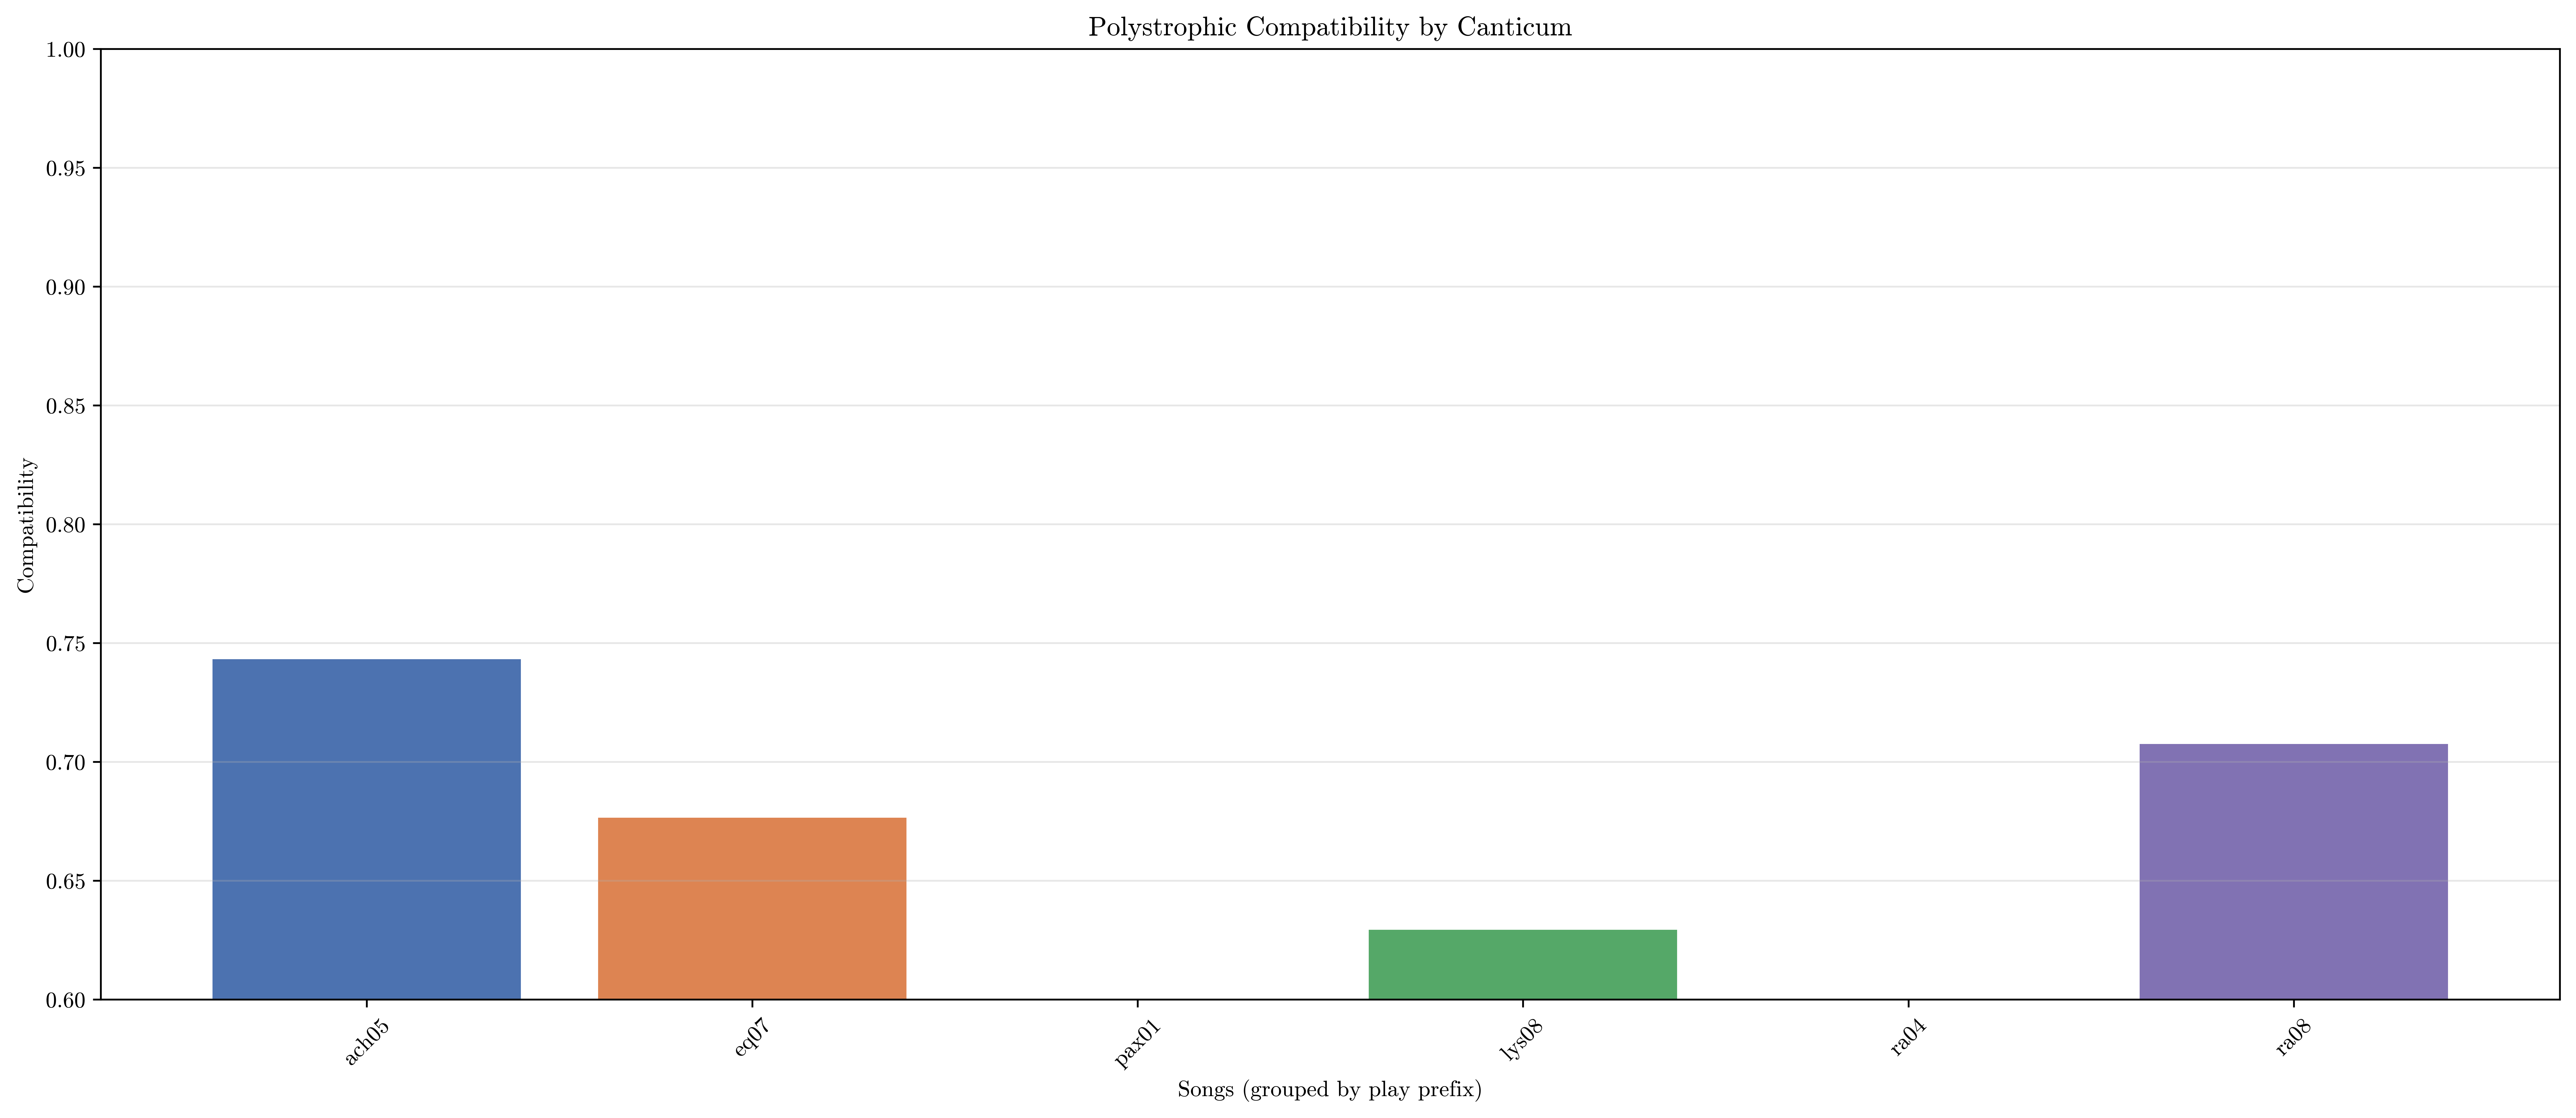

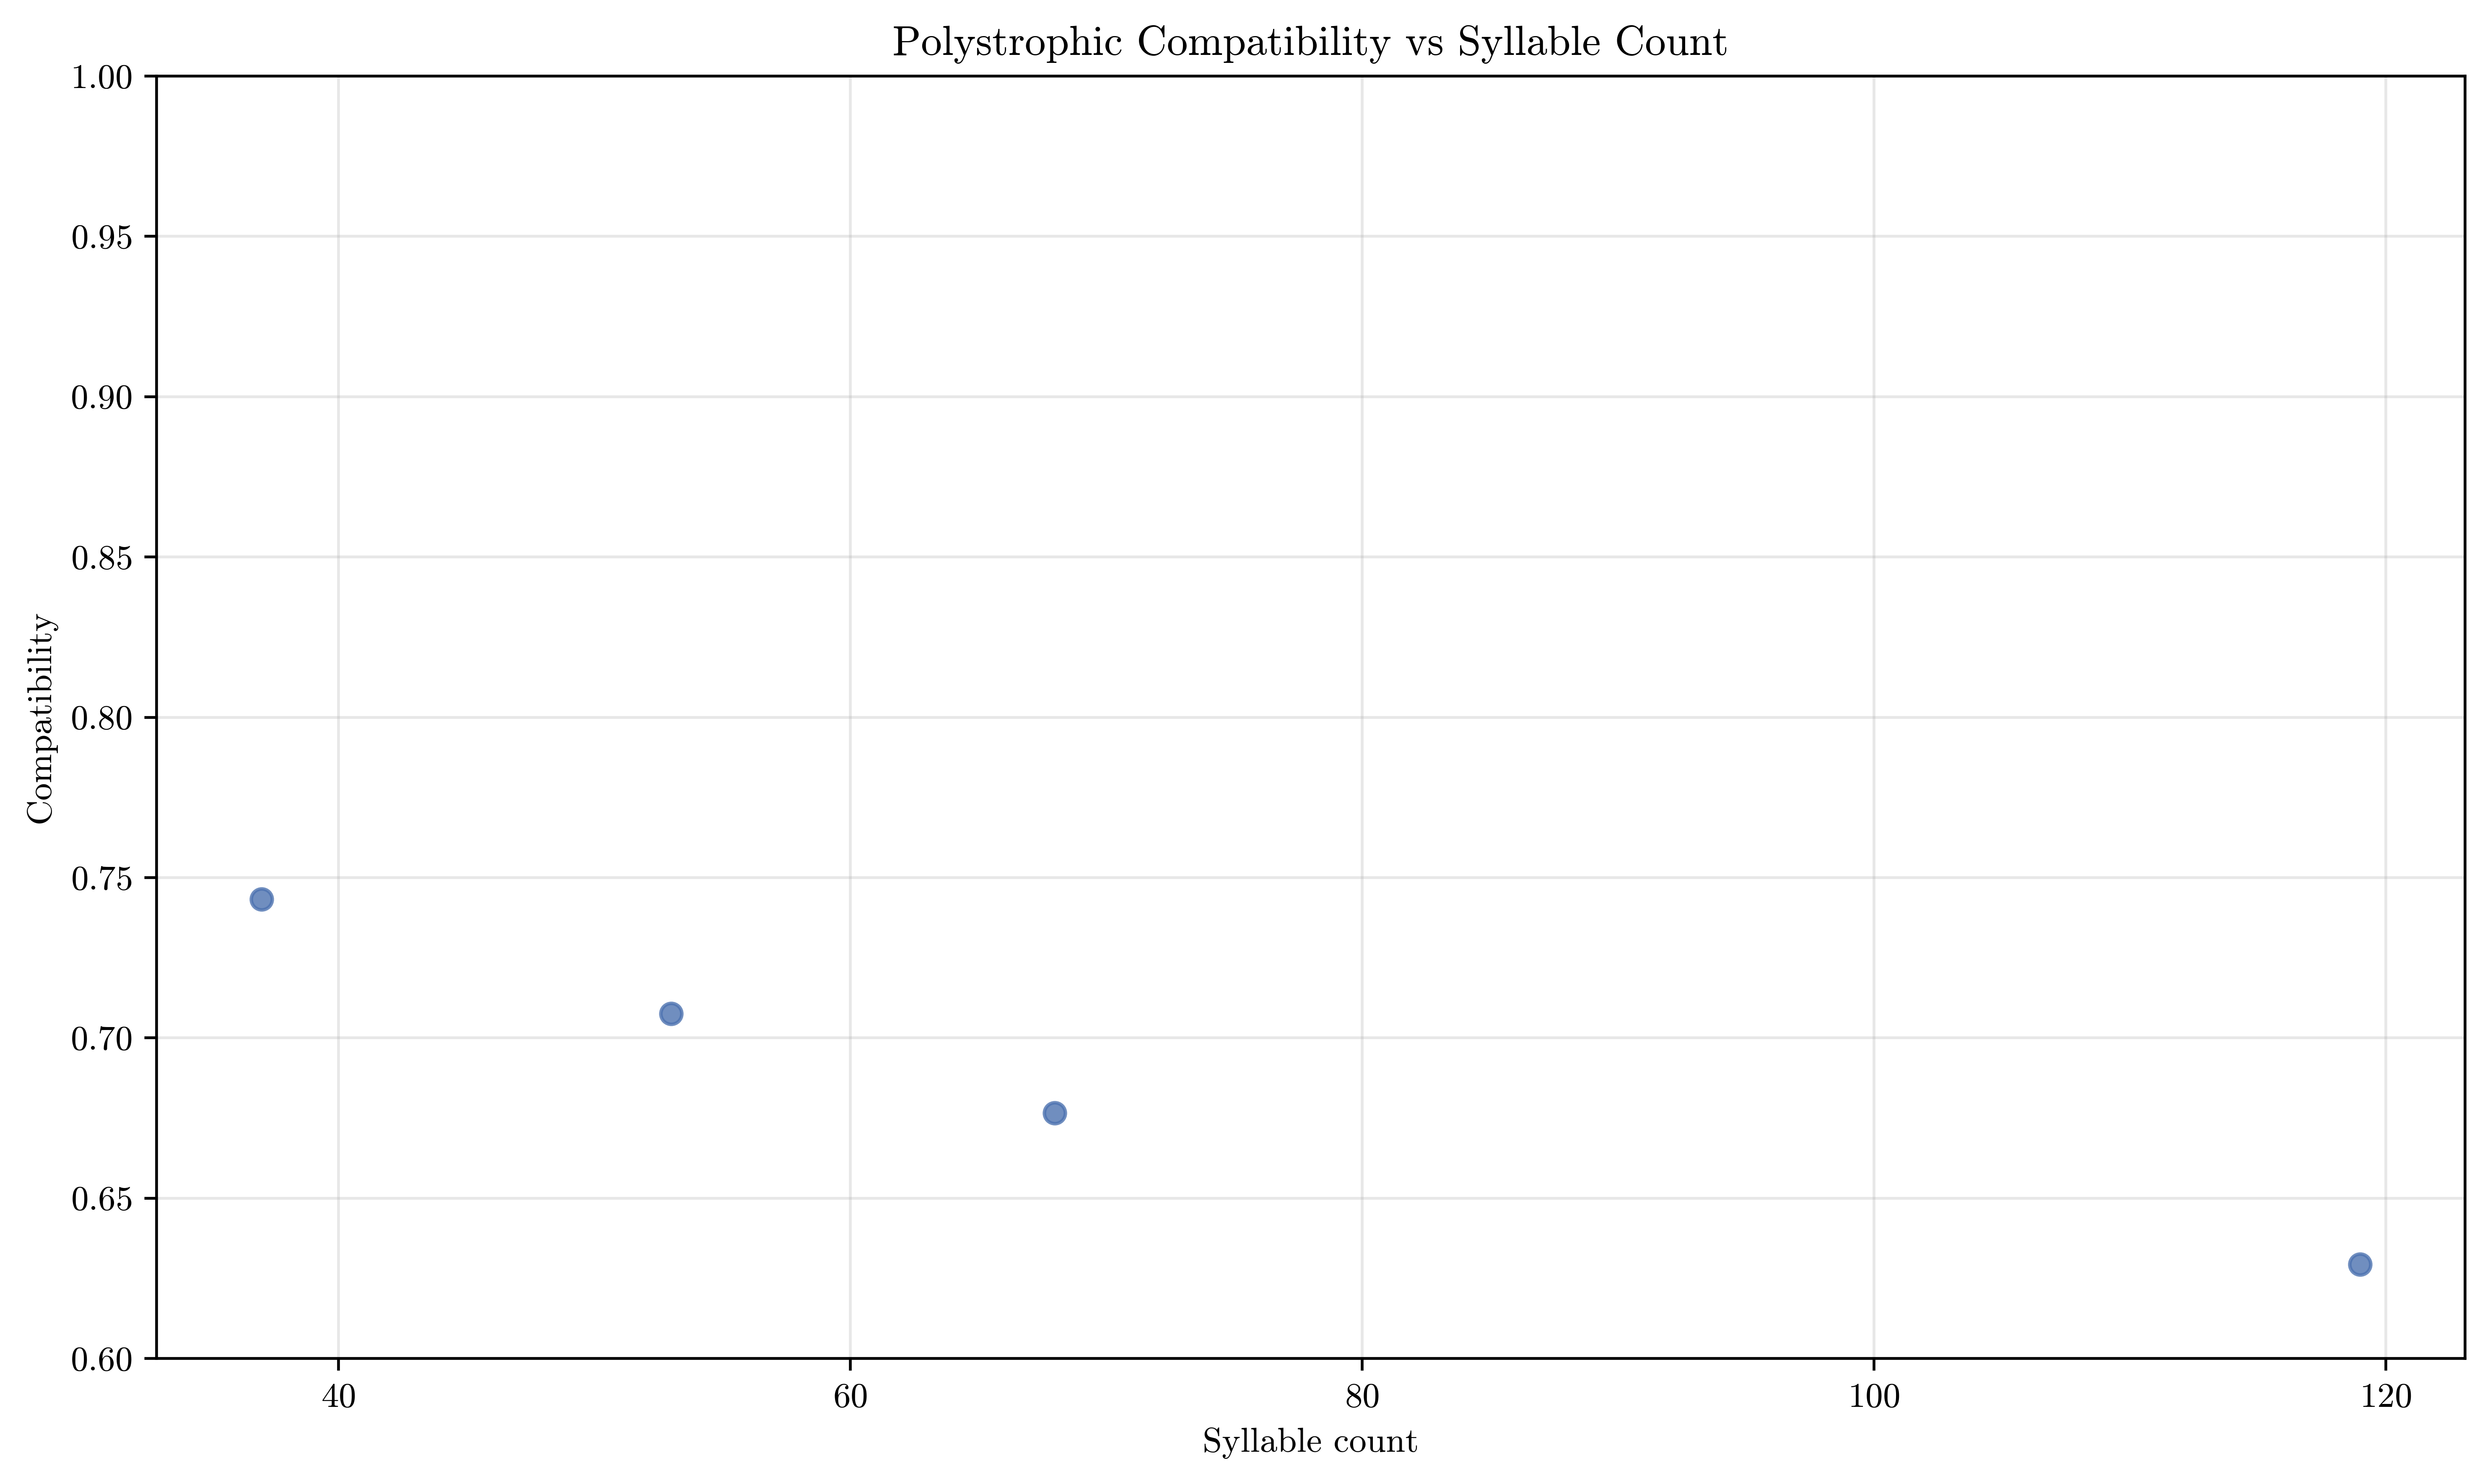

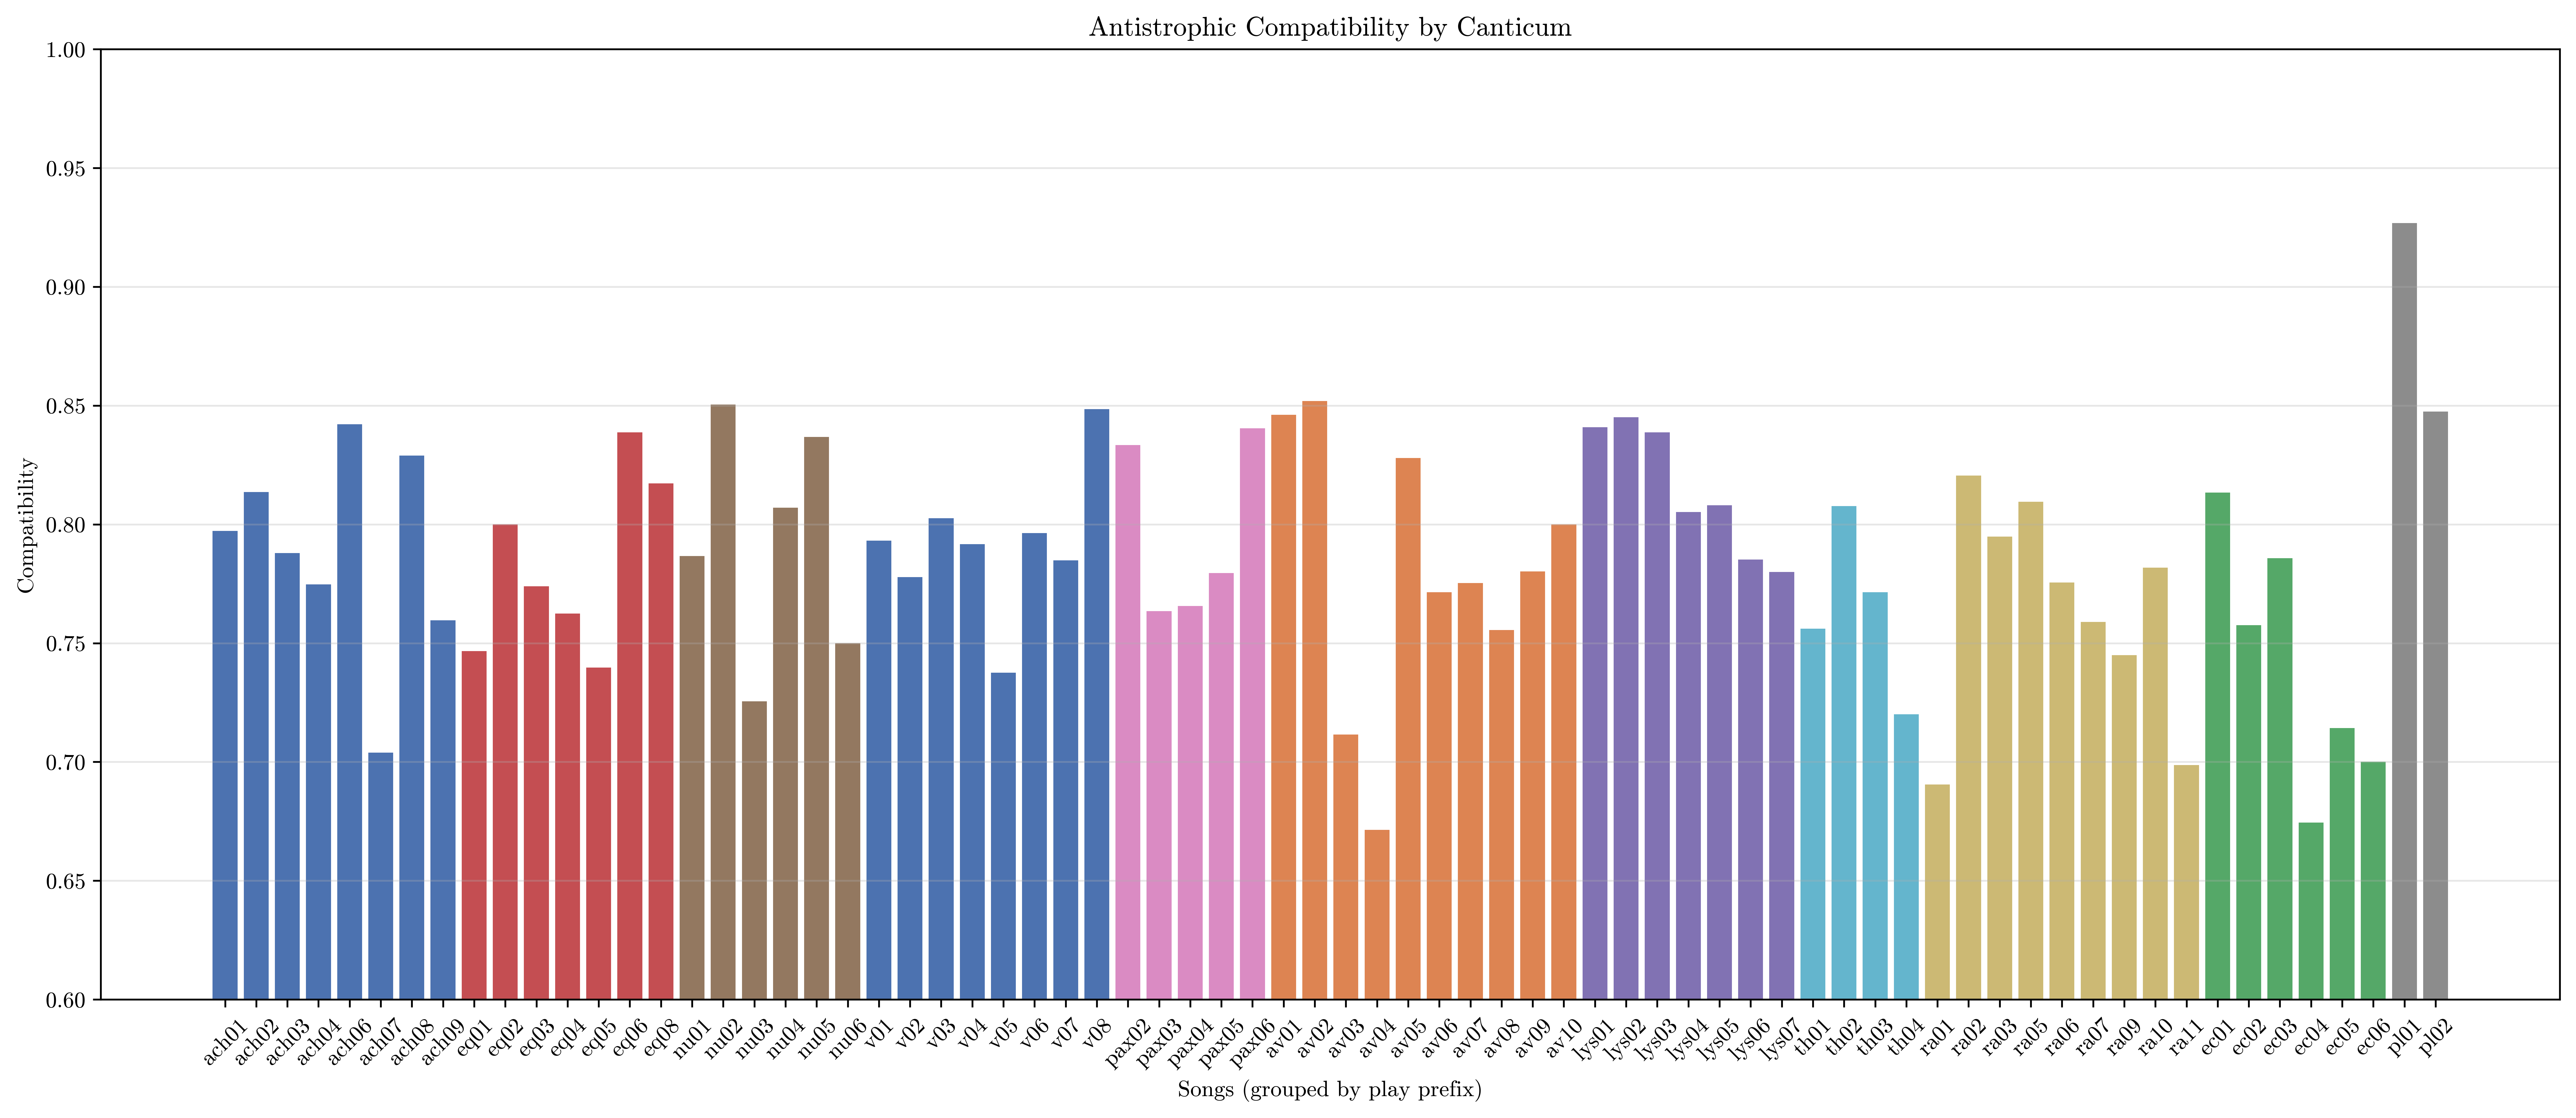

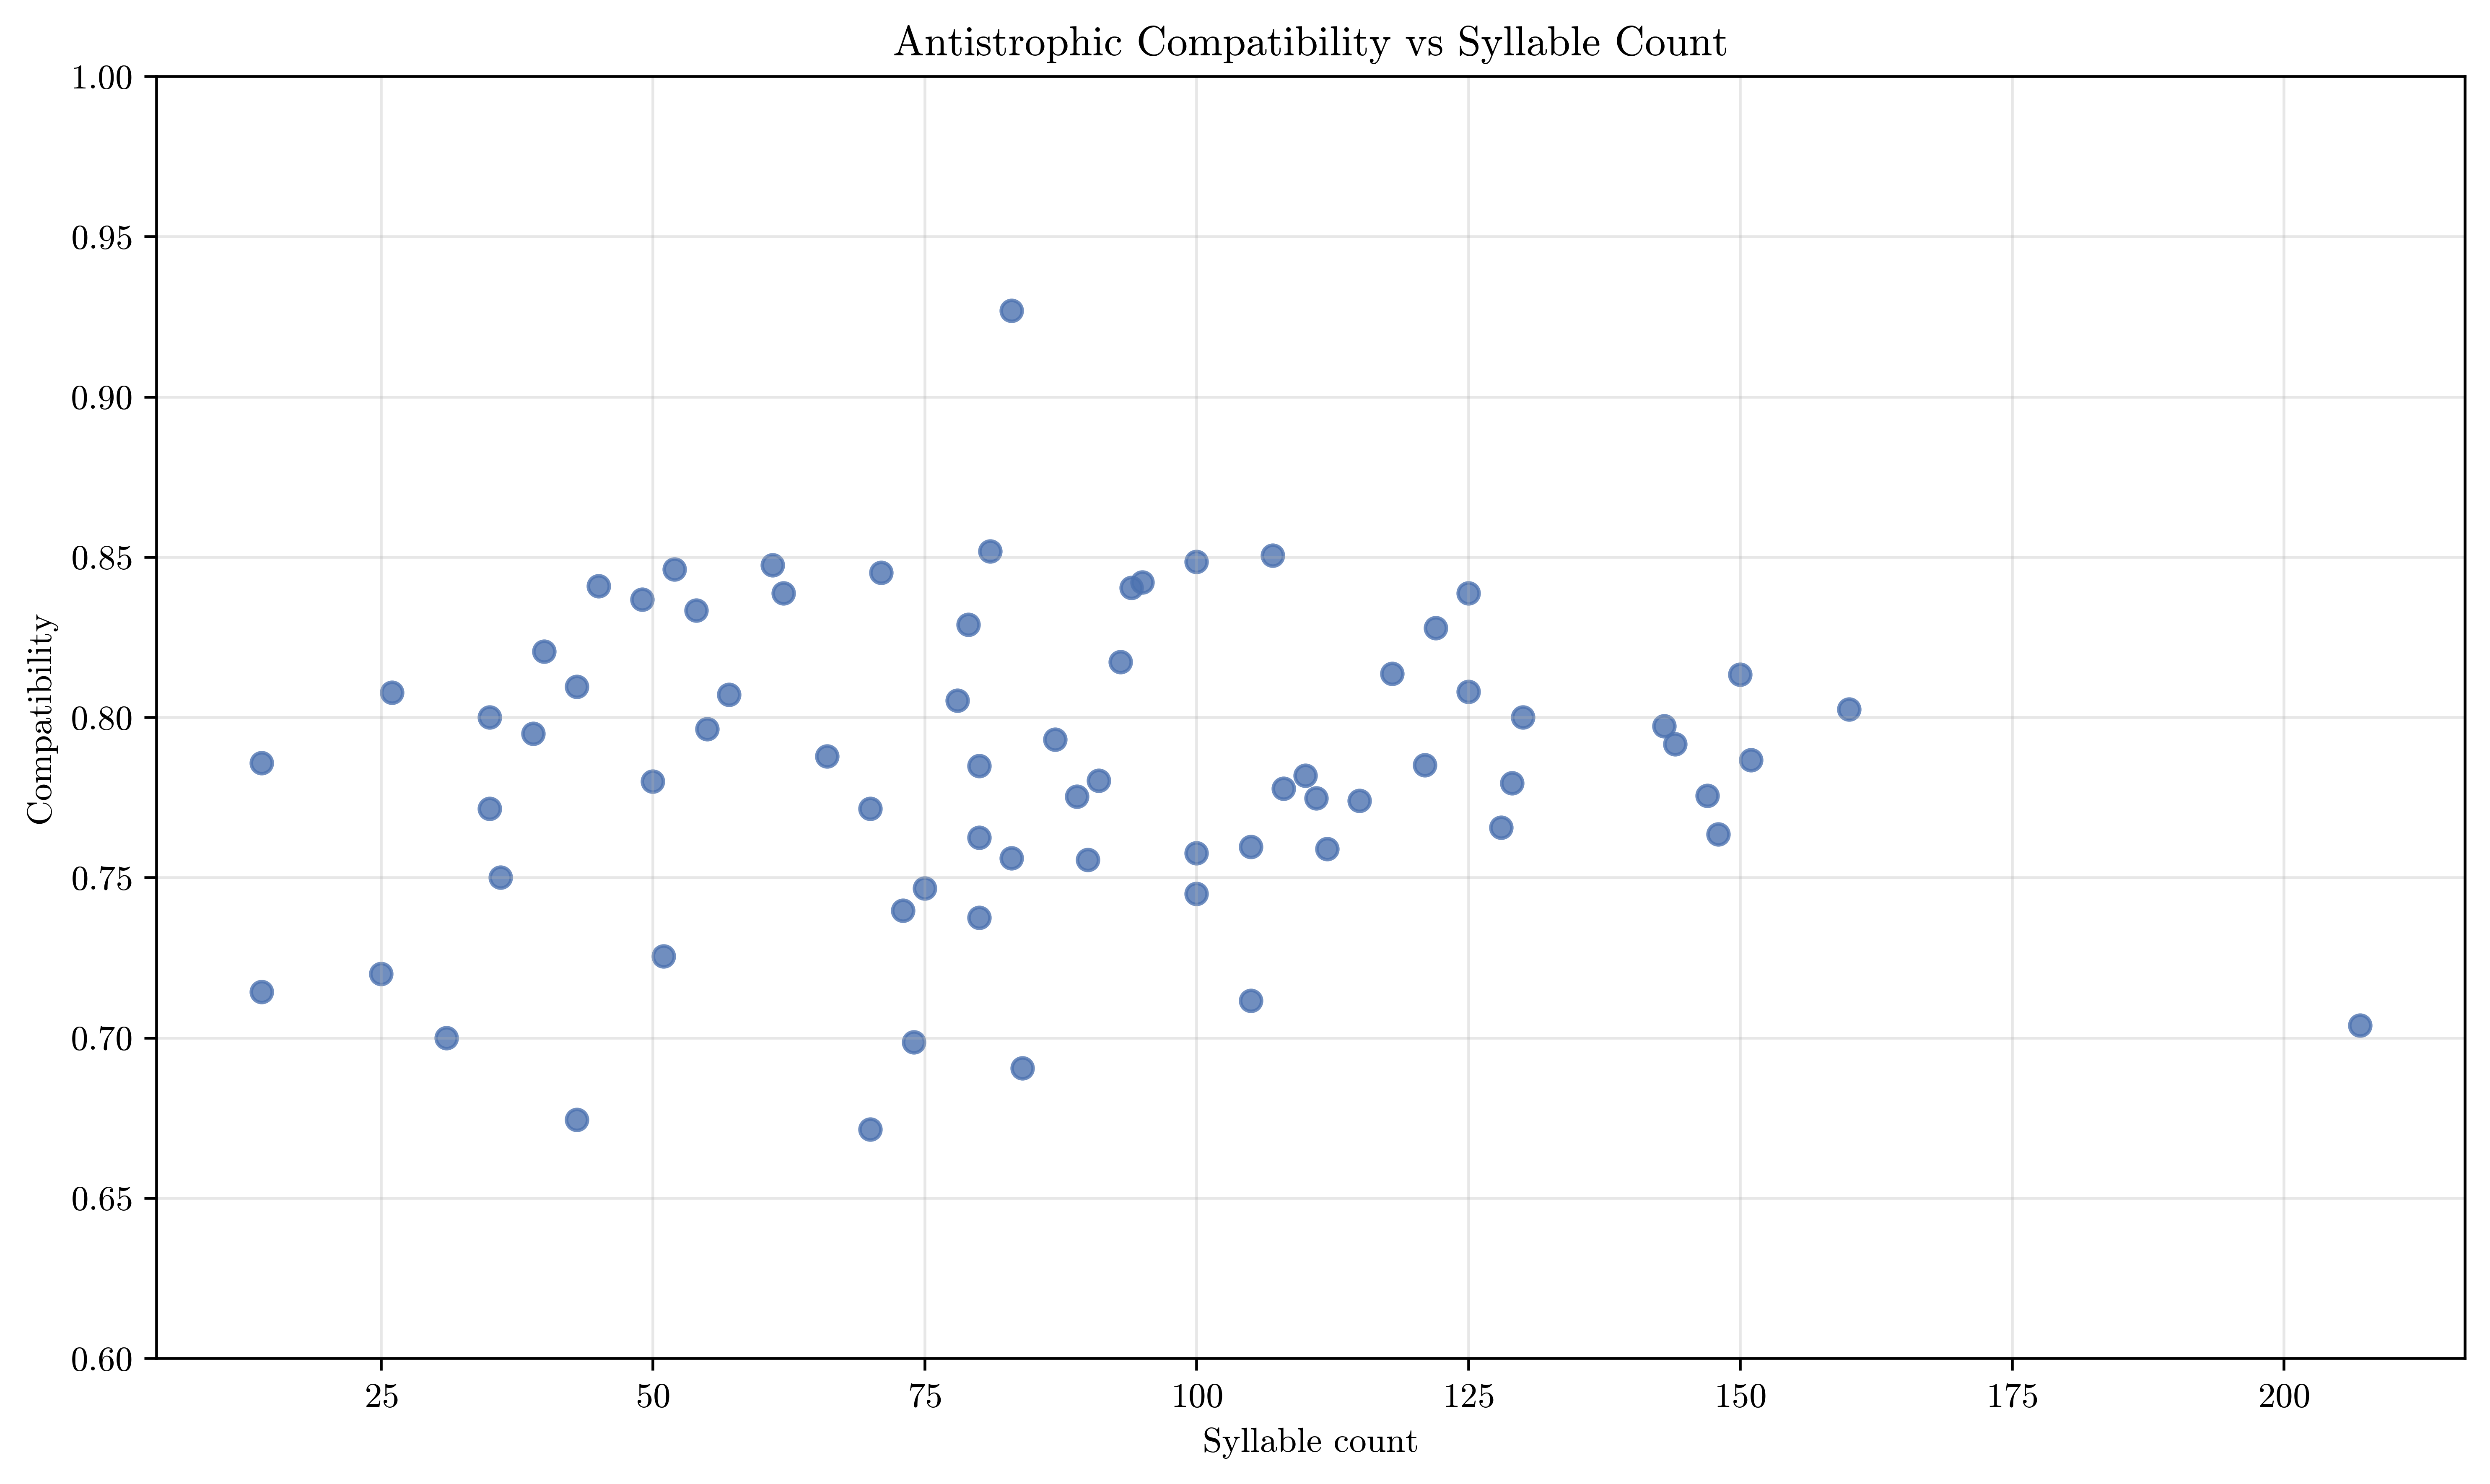

In [ ]:
from responsio_accentuum import compatibility_canticum, compatibility_ratios_to_stats, compatibility_strophicity
from aristophanis_cantica.utils.utils import abbreviations, get_strophicity, get_syll_count

import matplotlib.pyplot as plt
import numpy as np
from aristophanis_cantica.plot import apply_plotting_poetry_palette

apply_plotting_poetry_palette()
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

def prepare_compatibility_stat_canticum(canticum_id):
    ratios = compatibility_canticum(
        ROOT / f"data/compiled/responsion_{canticum_id[:-2]}_compiled.xml",
        canticum_id,
    )
    return compatibility_ratios_to_stats(ratios)  # keep Fraction upstream

antistrophic_stat = compatibility_ratios_to_stats(
    compatibility_strophicity(ROOT / "data/compiled", mode="antistrophic")
)
polystrophic_stat = compatibility_ratios_to_stats(
    compatibility_strophicity(ROOT / "data/compiled", mode="polystrophic")
)
print(f"Antistrophic compatibility: {antistrophic_stat} ({float(antistrophic_stat):.6f})")
print(f"Polystrophic compatibility: {polystrophic_stat} ({float(polystrophic_stat):.6f})")

polystrophic_ids, antistrophic_ids = get_strophicity(abbreviations)
syll_counts_polystrophic = get_syll_count(polystrophic_ids)
syll_counts_antistrophic = get_syll_count(antistrophic_ids)

# Keep exact values first
polystrophic_dict_fraction = {}
for canticum_id in polystrophic_ids:
    polystrophic_dict_fraction[canticum_id] = prepare_compatibility_stat_canticum(canticum_id)

antistrophic_dict_fraction = {}
for canticum_id in antistrophic_ids:
    antistrophic_dict_fraction[canticum_id] = prepare_compatibility_stat_canticum(canticum_id)

# Convert only at plotting boundary
polystrophic_dict = {k: float(v) for k, v in polystrophic_dict_fraction.items()}
antistrophic_dict = {k: float(v) for k, v in antistrophic_dict_fraction.items()}

def plot_group_bar(metric_dict, title, y_start=0.6, y_end=1.0):
    keys = list(metric_dict.keys())
    values = np.array([metric_dict[k] for k in keys], dtype=float)

    prefixes = [k[:-2] for k in keys]
    unique_prefixes = sorted(set(prefixes))
    prefix_to_color = {
        prefix: default_colors[i % len(default_colors)]
        for i, prefix in enumerate(unique_prefixes)
    }
    bar_colors = [prefix_to_color[k[:-2]] for k in keys]

    plt.figure(figsize=(16, 7))
    plt.bar(keys, values, color=bar_colors)
    plt.xlabel("Songs (grouped by play prefix)")
    plt.ylabel("Compatibility")
    plt.title(title)
    plt.xticks(rotation=45)
    plt.ylim(y_start, y_end)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_points_by_syllables(metric_dict, syll_count_dict, title, y_start=0.6, y_end=1.0):
    common_ids = [k for k in metric_dict if k in syll_count_dict]
    x = np.array([float(syll_count_dict[k]) for k in common_ids], dtype=float)
    y = np.array([float(metric_dict[k]) for k in common_ids], dtype=float)

    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, color=default_colors[0], alpha=0.8)
    plt.xlabel("Syllable count")
    plt.ylabel("Compatibility")
    plt.title(title)
    plt.ylim(y_start, y_end)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_group_bar(polystrophic_dict, "Polystrophic Compatibility by Canticum", y_start=0.6, y_end=1.0)
plot_points_by_syllables(
    polystrophic_dict,
    syll_counts_polystrophic,
    "Polystrophic Compatibility vs Syllable Count",
    y_start=0.6,
    y_end=1.0,
)

plot_group_bar(antistrophic_dict, "Antistrophic Compatibility by Canticum", y_start=0.6, y_end=1.0)
plot_points_by_syllables(
    antistrophic_dict,
    syll_counts_antistrophic,
    "Antistrophic Compatibility vs Syllable Count",
    y_start=0.6,
    y_end=1.0,
)